# Task 4 — Steps 1 & 2: Embedding Blocking + Known-Pair Exclusion

Produces a **ranked candidate pool** for each dataset:
- **Step 1** — PyDI `EmbeddingBlocker` retrieves the top-k=20 nearest right-side neighbours for every left entity using `all-MiniLM-L6-v2` embeddings.
- **Step 1b** — Cosine similarity scores are computed from the same embeddings and added to the candidate table (PyDI does not return scores from `materialize()`).
- **Step 2** — Any pair that already appears in train/valid/test is removed.
- **Step 2b** — **Train-only filter**: the pool is restricted to candidate pairs whose entities are both TRAIN entities, so augmentation never introduces a held-out entity (CLAUDE.md entity-disjoint policy; `thesis-docs/methodology_review.md`, Issues 1 & 5). On WDC this is fully test-disjoint; on DBLP (non-disjoint benchmark) it is "as disjoint as the baseline". **Requires `data/raw/` to be present** — `entity_splits` now raises if it is missing (previously this filter silently no-op'd on Colab).

**Output files** (used by the seed-labeling notebook):
- `data/processed/<dataset>/candidates_pool.csv` — columns: `id1, id2, sim_score`, sorted descending
- `data/processed/<dataset>/entities_left.csv` — left entity table with `text` column
- `data/processed/<dataset>/entities_right.csv` — right entity table with `text` column

**To reuse**: change only `DATASET` in the Configuration cell.

## Configuration

In [1]:
DATASET = "dblp-scholar"   # "dblp-scholar" | "wdc-products"
TOP_K = 20               # nearest neighbours per left entity (Steiner & Bizer 2026)
MODEL = "sentence-transformers/all-MiniLM-L6-v2"
BATCH = 512              # embedding batch size

## Imports & paths

In [2]:
import gzip
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from PyDI.entitymatching import EmbeddingBlocker

ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT))

# Reuse serialization logic from preprocess.py — same COL/VAL format used in training
from src.data_prep.preprocess import serialize_record, WDC_COLS, DBLP_COLS

RAW_DBLP = ROOT / "data" / "raw" / "dblp-scholar"
RAW_WDC = ROOT / "data" / "raw" / "wdc-products"
PROCESSED = ROOT / "data" / "processed" / DATASET
DEBUG_DIR = ROOT / "experiments" / "blocking_debug" / DATASET
DEBUG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset : {DATASET}")
print(f"Output : {PROCESSED}")

Dataset : dblp-scholar
Output : /Users/abd/Developer/thesis-project/data/processed/dblp-scholar


## Step 1a — Load entity tables

In [3]:
if DATASET == "dblp-scholar":
    # Flat entity tables already exist
    table_a = pd.read_csv(RAW_DBLP / "tableA.csv")
    table_b = pd.read_csv(RAW_DBLP / "tableB.csv")
    table_a.columns = [c.lower() for c in table_a.columns]
    table_b.columns = [c.lower() for c in table_b.columns]

    cols_a = [c for c in DBLP_COLS if c in table_a.columns]
    cols_b = [c for c in DBLP_COLS if c in table_b.columns]

    df_left = table_a[["id"] + cols_a].copy()
    df_right = table_b[["id"] + cols_b].copy()

    df_left["text"] = df_left.apply(lambda r: serialize_record(r.to_dict(), cols_a), axis=1)
    df_right["text"] = df_right.apply(lambda r: serialize_record(r.to_dict(), cols_b), axis=1)

    # Known pairs from split CSVs
    known_pairs = set()
    for split_name in ["train", "valid", "test"]:
        sp = pd.read_csv(RAW_DBLP / f"{split_name}.csv")
        sp.columns = [c.lower() for c in sp.columns]
        for _, row in sp.iterrows():
            known_pairs.add((int(row["ltable_id"]), int(row["rtable_id"])))

elif DATASET == "wdc-products":
    # Extract unique entities from all three pair files
    left_entities  = {}
    right_entities = {}
    known_pairs    = set()

    for gz_name in ["train_raw.json.gz", "valid_raw.json.gz", "test_raw.json.gz"]:
        gz_path = RAW_WDC / gz_name
        if not gz_path.exists():
            print(f"[warn] {gz_name} not found — skipping")
            continue
        with gzip.open(gz_path, "rt", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rec = json.loads(line)
                lid = int(rec["id_left"])
                rid = int(rec["id_right"])
                known_pairs.add((lid, rid))
                if lid not in left_entities:
                    left_entities[lid] = {"id": lid, **{col: rec.get(f"{col}_left", "") for col in WDC_COLS}}
                if rid not in right_entities:
                    right_entities[rid] = {"id": rid, **{col: rec.get(f"{col}_right", "") for col in WDC_COLS}}

    df_left  = pd.DataFrame(list(left_entities.values()))
    df_right = pd.DataFrame(list(right_entities.values()))
    df_left["text"]  = df_left.apply(lambda r: serialize_record(r.to_dict(), WDC_COLS), axis=1)
    df_right["text"] = df_right.apply(lambda r: serialize_record(r.to_dict(), WDC_COLS), axis=1)

else:
    raise ValueError(f"Unknown dataset: {DATASET}")

# Ensure id column is int for consistent lookup
df_left["id"]  = df_left["id"].astype(int)
df_right["id"] = df_right["id"].astype(int)

print(f"Left entities  : {len(df_left):,}")
print(f"Right entities : {len(df_right):,}")
print(f"Known pairs    : {len(known_pairs):,}")

Left entities  : 2,616
Right entities : 64,263
Known pairs    : 28,707


## Step 1b — Run PyDI EmbeddingBlocker

In [4]:
blocker = EmbeddingBlocker(
    df_left,
    df_right,
    text_cols=["text"],
    model=MODEL,
    index_backend="sklearn",
    metric="cosine",
    top_k=TOP_K,
    id_column="id",
    batch_size=BATCH,
    output_dir=str(DEBUG_DIR),
)

candidates = blocker.materialize()   # DataFrame: id1, id2  (no similarity scores)

candidates["id1"] = candidates["id1"].astype(int)
candidates["id2"] = candidates["id2"].astype(int)

In [5]:
print(f"Raw candidate pairs : {len(candidates):,}")

Raw candidate pairs : 52,320


## Step 1c — Add cosine similarity scores

PyDI's `materialize()` returns only `(id1, id2)` — no scores. We embed all entities with the same model and compute cosine similarity for each candidate pair via dot product on L2-normalised vectors.

In [ ]:
st_model = SentenceTransformer(MODEL)

print("Embedding left entities...")
emb_left = st_model.encode(
    df_left["text"].tolist(),
    batch_size=BATCH,
    show_progress_bar=True,
    convert_to_numpy=True,
)

print("Embedding right entities...")
emb_right = st_model.encode(
    df_right["text"].tolist(),
    batch_size=BATCH,
    show_progress_bar=True,
    convert_to_numpy=True,
)

# L2-normalise so dot product == cosine similarity
emb_left  = normalize(emb_left,  norm="l2")
emb_right = normalize(emb_right, norm="l2")

# Build id → embedding index
left_ids  = df_left["id"].tolist()
right_ids = df_right["id"].tolist()
left_idx  = {lid: emb_left[i]  for i, lid in enumerate(left_ids)}
right_idx = {rid: emb_right[i] for i, rid in enumerate(right_ids)}

print("Computing similarity scores...")
id1_arr = candidates["id1"].values
id2_arr = candidates["id2"].values
left_vecs  = np.array([left_idx[i]  for i in id1_arr])
right_vecs = np.array([right_idx[i] for i in id2_arr])
scores = (left_vecs * right_vecs).sum(axis=1)

candidates["sim_score"] = scores
candidates = candidates.sort_values("sim_score", ascending=False).reset_index(drop=True)

print(f"Score range : [{candidates['sim_score'].min():.4f}, {candidates['sim_score'].max():.4f}]")
print(f"Mean score : {candidates['sim_score'].mean():.4f}")

Embedding left entities...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Embedding right entities...


Batches:   0%|          | 0/126 [00:00<?, ?it/s]

## Step 2 — Exclude known pairs

In [ ]:
n_before = len(candidates)

# Exclude self-pairs (WDC Products shares entity IDs across left/right tables)
candidates = candidates[candidates["id1"] != candidates["id2"]].reset_index(drop=True)
n_self = n_before - len(candidates)

# Vectorised known-pair exclusion
pair_tuples = list(zip(candidates["id1"].tolist(), candidates["id2"].tolist()))
keep_mask = np.array([p not in known_pairs for p in pair_tuples])
pool = candidates[keep_mask].reset_index(drop=True)

n_removed = len(candidates) - len(pool)
print(f"Candidates before exclusion : {n_before:,}")
print(f"Self-pairs removed          : {n_self:,}")
print(f"Known pairs removed         : {n_removed:,}")
print(f"Final candidate pool        : {len(pool):,}")

Candidates before exclusion : 52,320
Self-pairs removed          : 0
Known pairs removed         : 10,925
Final candidate pool        : 41,395


In [ ]:
# Step 2b — Train-only candidate pool (entity-disjoint policy)
#
# Augmentation may only use TRAIN entities. The candidate pool was built over the
# full entity universe, so without this it pairs held-out valid/test entities into
# new (LLM-labeled) training pairs (methodology_review.md, Issue 1).
#
#   - WDC Products (entity-disjoint benchmark): train entities are disjoint from
#     valid/test, so this yields a fully test-disjoint augmentation pool.
#   - DBLP-Scholar (NON-disjoint benchmark, Issue 5): train entities also appear in
#     valid/test, so this makes augmentation "as (non-)disjoint as the baseline" —
#     it introduces no entity the baseline train set didn't already use. This is the
#     accepted-and-documented policy; a strict valid/test exclusion would collapse
#     the DBLP pool to a few hundred entities.
#
# NOTE: requires data/raw/ to be present (entity_splits raises if it is missing —
# this is what previously failed silently when run on Colab without the raw data).
from src.data_prep.entity_splits import train_keep_sets, heldout_entity_ids

# (keep_id1, keep_id2) handle WDC's shared id space vs DBLP's separate tableA/tableB
# id spaces automatically.
keep_id1, keep_id2 = train_keep_sets(DATASET)

n_before_disjoint = len(pool)
keep_mask = pool["id1"].isin(keep_id1) & pool["id2"].isin(keep_id2)
pool = pool[keep_mask].reset_index(drop=True)
n_nontrain_excluded = n_before_disjoint - len(pool)

# Sanity: the surviving pool must touch 0 genuinely held-out (non-train) entities.
held1, held2 = heldout_entity_ids(DATASET)
n_heldout = int((pool["id1"].isin(held1) | pool["id2"].isin(held2)).sum())

print(f"Pool before train-only filter      : {n_before_disjoint:,}")
print(f"Non-train pairs removed            : {n_nontrain_excluded:,}")
print(f"Train-only candidate pool          : {len(pool):,}")
print(f"Held-out (non-train) entities left : {n_heldout}   (must be 0)")
assert n_heldout == 0, "Train-only filter failed — held-out entities remain in the pool"

## Similarity distribution of candidate pool

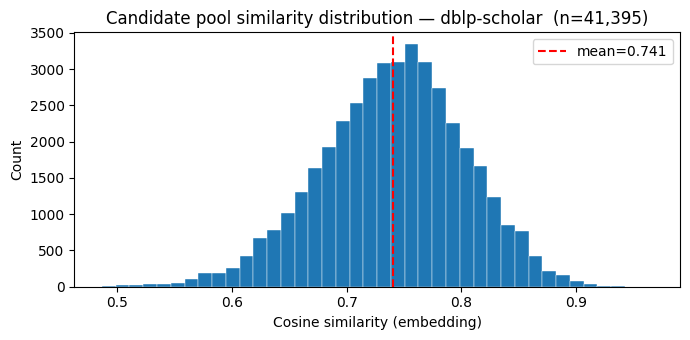


Top-5 highest-similarity candidate pairs:
  sim=0.9665  LEFT: COL title VAL implementing data cubes efficiently COL authors VAL v harinarayan , a rajaraman , j ul
           RIGHT: COL title VAL jd u1lman , '' COL authors VAL v harinarayan , a rajaraman COL venue VAL implementing 

  sim=0.9389  LEFT: COL title VAL querying xml views of relational data COL authors VAL j shanmugasundaram , j kiernan ,
           RIGHT: COL title VAL amd j COL authors VAL j shanmugasundaram , j kiernan , ej shekita , c fan COL venue VA

  sim=0.9342  LEFT: COL title VAL title COL authors VAL  COL venue VAL  COL year VAL 1995
           RIGHT: COL title VAL inc COL authors VAL c co COL venue VAL  COL year VAL 

  sim=0.9327  LEFT: COL title VAL sql standardization : the next steps COL authors VAL a eisenberg , j melton COL venue 
           RIGHT: COL title VAL the next steps , andrew eisenberg and jim melton COL authors VAL sql standardization C

  sim=0.9317  LEFT: COL title VAL title , foreword , pref

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(pool["sim_score"], bins=40, color="#1f77b4", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Cosine similarity (embedding)")
ax.set_ylabel("Count")
ax.set_title(f"Candidate pool similarity distribution — {DATASET}  (n={len(pool):,})")
ax.axvline(pool["sim_score"].mean(), color="red", linestyle="--", label=f"mean={pool['sim_score'].mean():.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED / f"candidate_pool_similarity_hist_{DATASET}.png", dpi=300)
plt.show()

# Spot-check top-5 pairs
print("\nTop-5 highest-similarity candidate pairs:")
right_text_map = df_right.set_index("id")["text"].to_dict()
left_text_map  = df_left.set_index("id")["text"].to_dict()
for _, row in pool.head(5).iterrows():
    lt = left_text_map[row.id1][:100]
    rt = right_text_map[row.id2][:100]
    print(f"  sim={row.sim_score:.4f}  LEFT: {lt}")
    print(f"           RIGHT: {rt}")
    print()

## Save outputs

In [ ]:
PROCESSED.mkdir(parents=True, exist_ok=True)

# Candidate pool
pool_path = PROCESSED / "candidates_pool.csv"
pool[["id1", "id2", "sim_score"]].to_csv(pool_path, index=False)
print(f"Saved candidate pool     → {pool_path}")

# Entity tables (needed by Step 3 for LLM prompt construction)
left_path  = PROCESSED / "entities_left.csv"
right_path = PROCESSED / "entities_right.csv"
df_left.to_csv(left_path, index=False)
df_right.to_csv(right_path, index=False)
print(f"Saved left entities      → {left_path}")
print(f"Saved right entities     → {right_path}")

Saved candidate pool     → /content/data/processed/dblp-scholar/candidates_pool.csv
Saved left entities      → /content/data/processed/dblp-scholar/entities_left.csv
Saved right entities     → /content/data/processed/dblp-scholar/entities_right.csv


## Summary

In [ ]:
summary = {
    "dataset": DATASET,
    "embedding_model": MODEL,
    "top_k": TOP_K,
    "left_entities": len(df_left),
    "right_entities": len(df_right),
    "max_possible_pairs": len(df_left) * len(df_right),
    "raw_candidates": n_before,
    "known_pairs_excluded": n_removed,
    "nontrain_pairs_excluded": n_nontrain_excluded,
    "heldout_entities_remaining": n_heldout,
    "final_pool_size": len(pool),
    "pool_sim_mean": round(float(pool["sim_score"].mean()), 4),
    "pool_sim_min": round(float(pool["sim_score"].min()), 4),
    "pool_sim_max": round(float(pool["sim_score"].max()), 4),
    # "pair_completeness": round(float(blocker.pair_completeness), 4),
    # "reduction_ratio": round(float(blocker.reduction_ratio), 6),
}

print(f"{'Metric':<32} {'Value':>12}")
print("-" * 46)
for k, v in summary.items():
    print(f"{k:<32} {str(v):>12}")

# Persist summary alongside outputs
import json as _json
summary_path = PROCESSED / "candidates_pool_summary.json"
with open(summary_path, "w") as f:
    _json.dump(summary, f, indent=2)
print(f"\nSummary saved → {summary_path}")